In [3]:
#librerías y config. gráficos

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import time

def initialize_plotting():
    import matplotlib as mpl
    %config InlineBackend.figure_format = 'svg'
    label_size = 20
    mpl.rcParams['xtick.labelsize'] = label_size
    mpl.rcParams['ytick.labelsize'] = label_size
    mpl.rcParams['legend.fontsize'] = 14
    plt.rc('font', family='serif')
    mpl.rcParams.update({'font.size': 16})
    mpl.rcParams['text.usetex'] = False
    mpl.rcParams['figure.dpi'] = 120
initialize_plotting()

In [5]:
#Pregunta 1#

#(a) Conceptual en pdf

#(b) Construir Hamiltoniano para hbar=1

#definimos la identidad, sigmax y sigmaz

I = np.array([[1, 0], [0, 1]], dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

#definimos el operador sigma^alpha_j:

def sigma_aj(op, pos, N): #op:operador de pauli respectivo pos:posicion en la que actúa, N: número de partículas
    res = op if pos == 1 else I #define el operador de pauli en la 1ra pos solo si se actúa en ahí
    for i in range(2, N+1):  #bucle para el resto de posiciones que revisa en que posicion debe ir el operador
        if i == pos:
            res = np.kron(res, op)   #np.kron es el producto tensorial entre operadores
        else:
            res = np.kron(res, I)
    return res

# Construimos el camiltoniano de Ising

def build_Ham(N, J, B):
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex) #genera matriz vacía donde armar H

    for i in range(1, N):
        sz_int = I if i > 1 else sz    #operados sigmaz entre i, i+1
        for k in range(2, N+1):
            if k == i or k == i + 1:
                sz_int = np.kron(sz_int, sz)
            else:
                sz_int = np.kron(sz_int, I)
        H += J * sz_int
    for i in range(1, N+1):
        H += B * sigma_aj(sx, i, N)
    return H

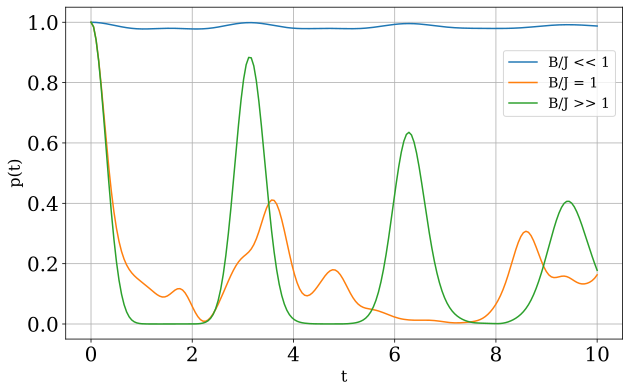

In [12]:
#(c) operador evolución y simulacion 

def simular_evolucion(N, J, B, t_max, steps):
    H = build_Ham(N, J, B)
    tiempos = np.linspace(0, t_max, steps)

    psi_0 = np.zeros(2**N, dtype=complex) #vector columna dinde definiremos el estado inicial
    psi_0[-1] = 1.0     #por convención, un 1 en la ultima pos indica el estado del enunciado

    prob = []   #lista vacía para guardar valores de probabilidad en cada paso

    val_prop, vec_prop = np.linalg.eigh(H) #valores propios y vectores propios de H

    c_n = vec_prop.T.conj() @ psi_0 # calcula los coef de la expasion de psi_t 

    for t in tiempos:
        phases = np.exp(-1j * val_prop * t)
        psi_t = vec_prop @ (c_n * phases)

        overlap = np.vdot(psi_0, psi_t)
        prob.append(np.abs(overlap)**2)

    return tiempos, prob

N = 6
t_max = 10
steps = 200

cases = [
    (1.0, 0.1, "B/J << 1"),
    (1.0, 1.0, "B/J = 1"),
    (0.1, 1.0, "B/J >> 1")
]

plt.figure(figsize=(10,6))
for J, B, label in cases:
    t_vals, p_vals = simular_evolucion(N, J, B, t_max, steps)
    plt.plot(t_vals, p_vals, label=label)

plt.xlabel("t")
plt.ylabel("p(t)")
plt.legend(loc = 'upper right', bbox_to_anchor=(1.0, 0.89))
plt.grid(True)
plt.show()

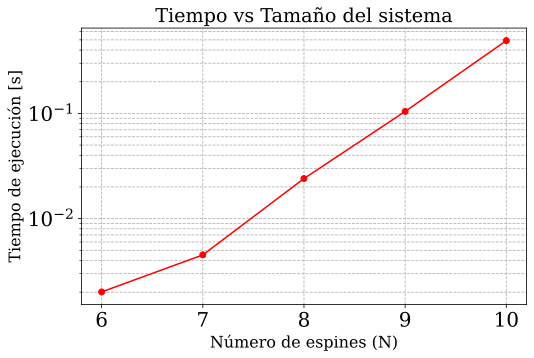

In [16]:
# incisos (d) y (e)
N_vals = [6, 7, 8, 9, 10]
tiempos_promedio = []
realizaciones = 5

for n in N_vals:
    t_n = []
    for _ in range(realizaciones):
        inicio = time.perf_counter()
        H_test = build_Ham(n, J=1.0, B=1.0)
        np.linalg.eigh(H_test)
        fin = time.perf_counter()
        t_n.append(fin - inicio)
    tiempos_promedio.append(np.mean(t_n))

plt.figure(figsize=(8, 5))
plt.plot(N_vals, tiempos_promedio, marker='o', linestyle='-', color='r')
plt.xlabel("Número de espines (N)")
plt.ylabel("Tiempo de ejecución [s]")
plt.title("Tiempo vs Tamaño del sistema")
plt.yscale('log') # Escala logarítmica para ver la tendencia lineal
plt.grid(True, which="both", ls="--")
plt.show()